# Figure 4b – Wilson B-factor correlation vs RMSD perturbation

Reads `data/processed/figure_4b_bfactors.csv` and `figure_4b_trend.csv`.
Saves `figures/figure_4b_scatter.png` and `figures/figure_4b_trend.png`.


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

cwd = Path.cwd()
ROOT_DIR = cwd.parent if cwd.name == 'notebooks' else cwd
sys.path.insert(0, str(ROOT_DIR / 'notebooks'))
from plot_utils import setup_style, plot_correlations_multiple, pretty_lineplot_XY

PROCESSED = ROOT_DIR / 'data' / 'processed'
FIGURES   = ROOT_DIR / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

setup_style(font_scale=2.0)


Saved figures/figure_4b_scatter.png


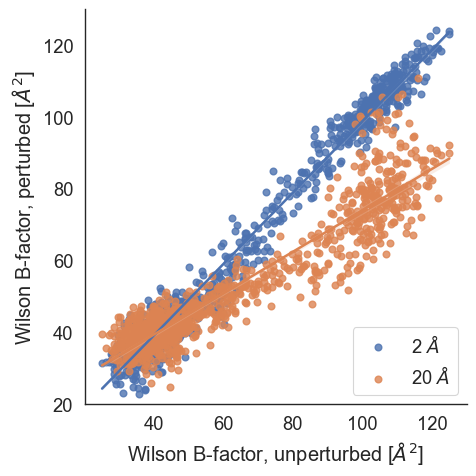

In [7]:
df_bf    = pd.read_csv(PROCESSED / 'figure_4b_bfactors.csv')
df_trend = pd.read_csv(PROCESSED / 'figure_4b_trend.csv')

bf_0 = df_bf['bfactor_0pm'].values
bf_200 = df_bf['bfactor_200pm'].values
bf_2000 = df_bf['bfactor_2000pm'].values
# # Scatter plot: RMSD 2 A (200 pm) and 20 A (2000 pm) vs RMSD 0
# fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# for ax, rmsd_pm, rmsd_a in zip(axes, [200, 2000], [2, 20]):
#     bf = df_bf[f'bfactor_{rmsd_pm}pm'].values
#     ax.scatter(bf_0, bf, alpha=0.1, s=8, color='steelblue')
#     ax.set_xlabel(r'Wilson B-factor, unperturbed [$\AA^{2}$]', fontsize=11)
#     ax.set_ylabel(r'Wilson B-factor, perturbed [$\AA^{2}$]', fontsize=11)
#     ax.set_title(f'RMSD = {rmsd_a} ' + r'$\AA$', fontsize=11)
#     ax.set_xlim(20, 130)
#     ax.set_ylim(20, 130)

bfactor_arrays_tuple = [(bf_0, bf_200, f"2 $\AA$"), (bf_0, bf_2000, f"20 $\AA$")]
fig = plot_correlations_multiple(
    bfactor_arrays_tuple,
    scatter=True,
    x_label=r'Wilson B-factor, unperturbed [$\AA^{2}$]',
    y_label=r'Wilson B-factor, perturbed [$\AA^{2}$]',
    alpha=0.1,
    ylims=(20, 130),
    fontscale=1.5,
    figsize=(8,2)
)

fig.savefig(FIGURES / 'figure_4b_scatter.png', dpi=300, bbox_inches='tight', format='png')
print('Saved figures/figure_4b_scatter.png')


Saved figures/figure_4b_trend.png


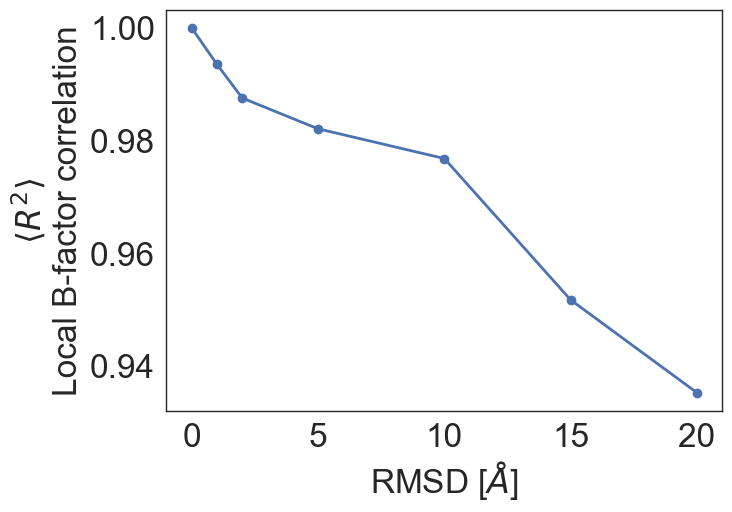

In [6]:
# Trend plot: Pearson r vs RMSD
fig2, ax2 = plt.subplots(figsize=(7, 5))
ax2.plot(df_trend['rmsd_A'], df_trend['pearson_r'], 'o-', linewidth=2, markersize=6)
ax2.set_xlabel(r'RMSD [$\AA$]', fontsize=24)
ax2.set_ylabel(r'$\langle R^2 \rangle$' + '\nLocal B-factor correlation', fontsize=24)
plt.tight_layout()
fig2.savefig(FIGURES / 'figure_4b_trend.png', dpi=300, bbox_inches='tight', format='png')
# fontsize for x and y axis ticks
ax2.tick_params(axis='both', which='major', labelsize=24)

print('Saved figures/figure_4b_trend.png')
